C:\Users\Muhammad Uzair\AppData\Local\Temp\ipykernel_17244\4053687738.py:30: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img1 = imread("image1.jpeg")  # Low-contrast image
C:\Users\Muhammad Uzair\AppData\Local\Temp\ipykernel_17244\4053687738.py:31: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img2 = imread("image2.jpeg")  # Dark/underexposed image


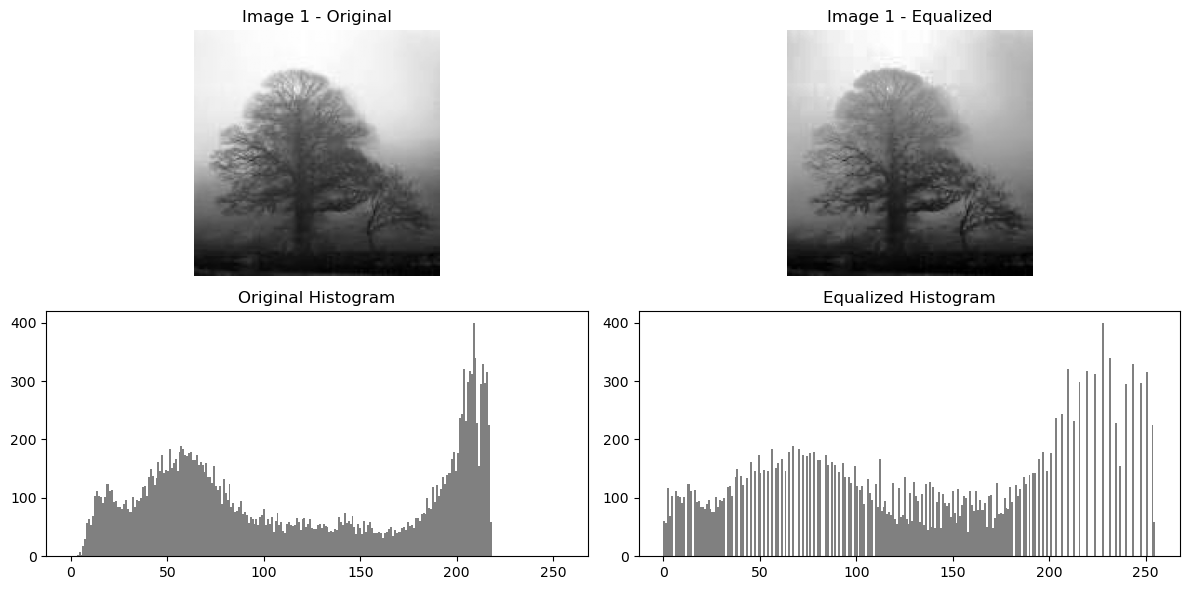

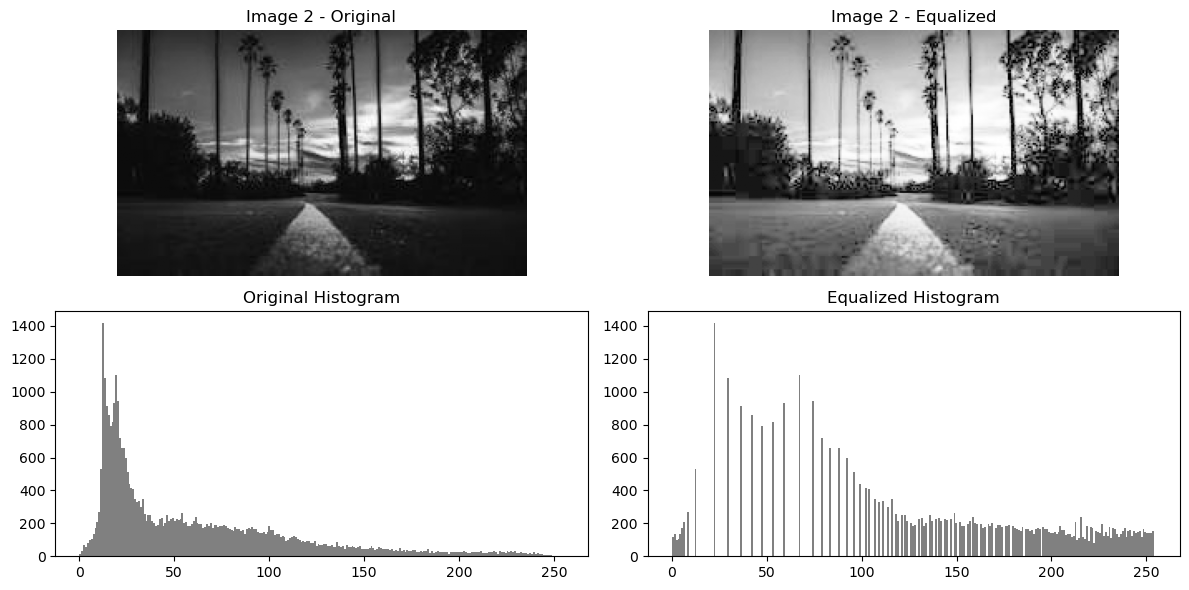

Transformation Mapping for Image 1:
[  0   0   0   0   0   0   0   0   1   2   2   3   4   6   7   8   9  10
  12  13  14  16  17  18  19  20  21  22  23  24  25  26  27  28  29  30
  31  33  34  35  37  38  40  41  43  45  47  49  50  52  54  56  58  59
  61  63  65  67  70  72  74  76  78  80  81  84  85  87  89  91  93  94
  96  97  99 100 102 103 104 106 107 108 110 111 112 112 113 114 115 116
 117 118 119 119 120 121 122 122 123 124 125 125 126 127 128 128 129 130
 130 131 131 132 132 133 134 134 135 136 136 137 138 138 139 140 140 141
 142 142 143 143 144 145 145 146 146 147 147 148 148 149 150 150 151 152
 153 153 154 155 155 156 156 157 157 158 159 159 160 160 161 161 162 162
 162 163 163 164 164 165 165 166 166 167 167 168 169 169 170 170 171 172
 173 173 174 175 176 177 178 179 180 181 183 184 185 187 188 190 192 193
 195 197 199 201 204 207 210 213 216 220 224 228 232 235 237 240 244 248
 251 254 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255
 255 255 255 25

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from imageio import imread

# ---------- Histogram Equalization from Scratch ----------
def histogram_equalization_manual(img):
    # Flatten image to 1D
    flat = img.flatten()
    
    # Compute histogram
    hist = np.zeros(256, dtype=int)
    for pixel in flat:
        hist[pixel] += 1
    
    # Normalize histogram (probability)
    hist_norm = hist / flat.size
    
    # Compute cumulative distribution function (CDF)
    cdf = np.cumsum(hist_norm)
    
    # Create transformation mapping
    transform_map = np.floor(255 * cdf).astype(np.uint8)
    
    # Apply transformation to get equalized image
    equalized_img = transform_map[img]
    
    return equalized_img, hist, transform_map

# ---------- Load Images ----------
img1 = imread("image1.jpeg")  # Low-contrast image
img2 = imread("image2.jpeg")  # Dark/underexposed image

# Convert to grayscale if RGB
if img1.ndim == 3:
    img1 = np.dot(img1[...,:3], [0.2989, 0.5870, 0.1140]).astype(np.uint8)
if img2.ndim == 3:
    img2 = np.dot(img2[...,:3], [0.2989, 0.5870, 0.1140]).astype(np.uint8)

# ---------- Apply Manual Histogram Equalization ----------
eq1, hist1, map1 = histogram_equalization_manual(img1)
eq2, hist2, map2 = histogram_equalization_manual(img2)

# ---------- Plot Results ----------
def plot_images_histograms(original, equalized, title):
    plt.figure(figsize=(12,6))

    plt.subplot(2,2,1)
    plt.imshow(original, cmap='gray')
    plt.title(f'{title} - Original')
    plt.axis('off')

    plt.subplot(2,2,2)
    plt.imshow(equalized, cmap='gray')
    plt.title(f'{title} - Equalized')
    plt.axis('off')

    plt.subplot(2,2,3)
    plt.hist(original.flatten(), bins=256, range=[0,255], color='gray')
    plt.title('Original Histogram')

    plt.subplot(2,2,4)
    plt.hist(equalized.flatten(), bins=256, range=[0,255], color='gray')
    plt.title('Equalized Histogram')

    plt.tight_layout()
    plt.show()

plot_images_histograms(img1, eq1, "Image 1")
plot_images_histograms(img2, eq2, "Image 2")

# ---------- Print Transformation Mapping ----------
print("Transformation Mapping for Image 1:")
print(map1)

print("\nTransformation Mapping for Image 2:")
print(map2)
